# Spotiflow in Python

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/00_spot_detection/spotiflow_notebook.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/00_spot_detection/spotiflow_notebook_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [ ]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "tifffile",
#     "spotiflow",
#     "ndv[jupyter,pygfx]",
#     "jupyter-rfb<=0.5.4",
#     "tqdm",
# ]
# ///

## Overview

[GitHub](https://github.com/weigertlab/spotiflow) | [Paper](https://www.nature.com/articles/s41592-025-02662-x) | [Spotiflow Documentation](https://weigertlab.org/spotiflow/index.html) | [Spotiflow API](https://weigertlab.org/spotiflow/api.html#)

In this notebook, we'll see how to run `Spotiflow` to detect spots on single images or on a folder of images, and how to visualize and save the results.

The images we will use for this section can be downloaded from the <a href="" download> <i class="fas fa-download"></i> Spot Detection Dataset</a>.

<p class="alert alert-warning">
    <strong>💡 Tip:</strong> <code>Spotiflow</code> runs significantly faster on a GPU. It supports both NVIDIA GPUs (CUDA) and Apple Silicon (MPS). If you don't have either, we recommend running this notebook on <a href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/00_spot_detection/spotiflow_notebook_colab.ipynb" target="_blank"> Google Colab</a> for faster performance.
</p>

<details>
<summary><b>NVIDIA GPU (CUDA - Windows/Linux)</b></summary>
<br>

In order to use Spotiflow in this notebook with an NVIDIA GPU:
1. you need to have the [NVIDIA drivers](https://www.nvidia.com/en-us/drivers/) installed on your system.
2. you can run `nvidia-smi` in the terminal to check your CUDA version (shown in the top-right of the output, e.g. `CUDA Version: 13.0.0`).
3. update the `# /// script` block at the top of this notebook to install the appropriate version of [PyTorch with CUDA support](https://pytorch.org/get-started/locally/) (replace `cu130` with your CUDA version):

```python
    # /// script
    # requires-python = ">=3.12"
    # dependencies = [
    #     "matplotlib",
    #     "tifffile",
    #     "spotiflow",
    #     "ndv[jupyter,pygfx]",
    #     "jupyter-rfb<=0.5.4",
    #     "torch",
    #     "torchvision",
    # ]
    #
    # [tool.uv.sources]
    # torch = { index = "pytorch-cu130" }
    # torchvision = { index = "pytorch-cu130" }
    #
    # [[tool.uv.index]]
    # name = "pytorch-cu130"
    # url = "https://download.pytorch.org/whl/cu130"
    # explicit = true
    # ///
```

4. re-run the notebook using `uvx juv run`.
</details>

## Import Libraries

In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
import tqdm
from spotiflow.model import Spotiflow

## Setup

These are a few helper functions that we will use later:

- `save_points_as_csv`: save the detected spots as a `napari`-compatible `csv` file.
- `split_points_by_channel`: split the spots returned by `predict_multichannel()` into one array per channel.
- `plot_points_by_channel`: overlay the detected spots on each channel of the image with `matplotlib` (or, with `is_3d=True`, on the maximum intensity projection of a `(Z, Y, X)` stack).

In [13]:
def save_points_as_csv(points, output_path="points.csv", channel_last=False) -> None:
    """Save points as a napari-compatible CSV (drag-and-drop as Points layer).

    napari maps the CSV columns (axis-0, axis-1, ...) to the layer axes in order.
    `predict_multichannel` returns the channel as the *last* column (e.g. (y, x, channel)),
    so set `channel_last=True` to move it to the front (e.g. (channel, y, x)) and have the
    spots line up with a channel-first (C, ...) image in napari.
    """
    points = np.asarray(points)
    if channel_last:
        # move the last column (channel) to the front
        points = points[:, [-1, *range(points.shape[1] - 1)]]
    ndim = points.shape[1]
    headers = ["index"] + [f"axis-{i}" for i in range(ndim)]
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for i, p in enumerate(points):
            writer.writerow([i, *p])


def split_points_by_channel(points, n_channels):
    """Split the points from `predict_multichannel` into one array per channel.

    `points` has the channel index as its last column (e.g. (y, x, channel)).
    Returns a tuple of length `n_channels`, where each element is an array with
    the spatial coordinates only (channel column dropped) of the spots detected
    in that channel, ready to be overlaid with matplotlib.
    """
    points = np.asarray(points)
    channels = points[:, -1].astype(int)
    coords = points[:, :-1]
    return tuple(coords[channels == c] for c in range(n_channels))


def plot_points_by_channel(image, points, colors=None, is_3d=False):
    """Overlay the detected spots on the image with matplotlib.

    2D multi-channel data (`is_3d=False`, default): `image` is channel-first
    (C, Y, X) and `points` (from `predict_multichannel`) has the channel index as
    its last column. One subplot per channel is shown with that channel's spots.

    3D single-channel data (`is_3d=True`): `image` is a (Z, Y, X) stack and
    `points` (from `predict`) are (z, y, x). The spots are overlaid on the maximum
    intensity projection along Z.
    """
    if is_3d:
        points = np.asarray(points)
        color = colors[0] if colors is not None else "red"
        plt.imshow(image.max(axis=0), cmap="gray")  # max intensity projection along Z
        plt.scatter(points[:, 2], points[:, 1], s=20, edgecolor=color, facecolor="none")
        plt.title(f"max projection ({len(points)} spots)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        return

    n_channels = image.shape[0]
    points_per_channel = split_points_by_channel(points, n_channels)
    fig, axs = plt.subplots(1, n_channels, figsize=(10, 5))
    axs = np.atleast_1d(axs)  # keep iterable when there is a single channel
    for ch, ax in enumerate(axs):
        spots = points_per_channel[ch]
        color = colors[ch] if colors is not None else "red"
        ax.imshow(image[ch], cmap="gray")
        ax.scatter(spots[:, 1], spots[:, 0], s=20, edgecolor=color, facecolor="none")
        ax.set_title(f"channel {ch} ({len(spots)} spots)")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Running Spotiflow on 2D images

### Load the Image

Since we will be using TIFF files, to load the images, we can use the `imread` method from the `tifffile` library.

In [ ]:
image_path = "../../_static/images/spots/2d_spots.tif"
image = tifffile.imread(image_path)

print(image.shape)

This is a 2-channel image, we can use the `imshow` method from the `ndv` library to visualize the image.

In [ ]:
ndv.imshow(
    image,
    channel_mode="composite",
    luts={0: {"cmap": "green"}, 1: {"cmap": "magenta"}},
)

In [ ]:
viewer = ndv.imshow(
    image,
    channel_mode="composite",
    luts={0: {"cmap": "green"}, 1: {"cmap": "magenta"}},
)

In [ ]:
viewer.widget().children[1].snapshot()

### Initialize the Model

To initialize a pre-trained `Spotiflow` model, we can use the [`from_pretrained()`](https://weigertlab.org/spotiflow/api.html#spotiflow.model.spotiflow.Spotiflow.from_pretrained) class method.

Currently the available pre-trained models are:

- `general`: trained on a diverse dataset of spots of different modalities acquired in different microscopes with different settings.
- `hybiss`: trained on HybISS data acquired in 3 different microscopes
- `synth_complex`: trained on synthetic data, which includes simulations of aberrated spots and fluorescence background.
- `fluo_live`: trained on live-cell fluorescence imaging data corresponding to the Telomeres and Terra datasets in the manuscript.
- `synth_3d`: trained on synthetic 3D data, which includes simulations of aberrated spots and Z-related artifacts.
- `smfish_3d`: fine-tuned from the synth_3d model on smFISH 3D data of Platynereis dumerilii.

For this first example, we'll use the `general` model.

<p class="alert alert alert-info">
    <strong>Note:</strong> If you never used <code>Spotiflow</code> before, the model you will specify in the <code>from_pretrained()</code> method will be downloaded automatically the first time you run this notebook.
</p>

In [ ]:
# Load a pretrained model
model = Spotiflow.from_pretrained("general")

### Run Spotiflow

After initializing the model, we can run `Spotiflow` on the image using either the [`predict()`](https://weigertlab.org/spotiflow/api.html#spotiflow.model.spotiflow.Spotiflow.predict) or the `predict_multichannel()` (see the dropdown below) method from the initialized model.

<details>
<summary><b><code>predict_multichannel()</code> Parameters</b></summary>
<br>

<pre><code>model.predict_multichannel(
    img,
    channels=None,
    **predict_kwargs,
)</code></pre>

**Input**

| Parameter | Default | Description |
|:---|:---|:---|
| `img` | — | Multi-channel image in **channel-last** format: `(Y, X, C)` for 2D or `(Z, Y, X, C)` for 3D. |
| `channels` | `None` | An `int` or a tuple of channel indices to run the detection on. If `None`, runs on all channels. |
| `**predict_kwargs` | — | Any keyword argument accepted by `predict()`, forwarded to each channel (see the useful ones below). |

**`predict()` keyword arguments**

| Parameter | Default | Description |
|:---|:---|:---|
| `prob_thresh` | `None` | Probability threshold for peak detection. If `None`, uses the model's optimal value. |
| `min_distance` | `1` | Minimum distance (in pixels) allowed between two detected spots. |
| `scale` | `None` | Rescale factor applied to the image before detection. |
| `subpix` | `None` | Whether to refine spot positions to subpixel accuracy using the stereographic flow. If `None`, deduced from the model configuration. |
| `normalizer` | `"auto"` | Intensity normalization. `"auto"` uses percentile-based normalization (`p_min=1`, `p_max=99.8`). |
| `device` | `None` | Compute device to use: `"auto"`, `"cpu"`, `"cuda"` or `"mps"`. If `None`, inferred from the model location. |

**Returns**

A tuple `(points, details)`:

| Output | Description |
|:---|:---|
| `points` | numpy array of spot coordinates: `(N, 3)` for 2D as `(y, x, channel)` or `(N, 4)` for 3D as `(z, y, x, channel)`. The **last column is the index of the channel** the spot was detected in. |
| `details` | A **list** with one entry per processed channel, each holding that channel's `heatmap` (probability heatmap per pixel), `intens` (intensities of the detected spots), `prob` (probability of each spot being a true positive), `flow` (stereographic flow vector field) and `subpix` (2D local offset vector field). |

</details>

<br>

The difference between the two is:

- `predict()` runs the model on a **single-channel** image (a 2D `(Y, X)` image or a 3D `(Z, Y, X)` stack) and returns the spots detected in it.

- `predict_multichannel()` is designed for multi-channel data. It runs `predict()` on **each channel independently** and stacks the results, tagging every spot with the channel it was detected in. This is needed because the pre-trained models always work on a single channel at a time.

Since we are using a 2-channel image, we will use `predict_multichannel()`.

<p class="alert alert alert-info">
    ⚠️ Spotiflow expects the <strong>channel axis to be last</strong> (the image must be in <code>(Y, X, C)</code> shape).
    <br><br>
    ⚠️ In our case, the image is stored as <code>(C, Y, X)</code> so we need to move the channel axis to the end before running the model. We can do this easily with <a href="https://numpy.org/doc/stable/reference/generated/numpy.transpose.html"><strong>`numpy.transpose`</strong></a>.
</p>

In [ ]:
tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
print(tr_image.shape)

Now we can run Spotiflow on the transposed image using the `predict_multichannel()`. Even though there could be useful parameters to use (e.g. `prob_thresh`, `min_distance`, `subpix`), for simplicity we will only pass the image to the function.

As shown in the dropdown above, `predict_multichannel()` will return two outputs (a tuple):

- `points`: a numpy array containing the coordinates of the detected spots.

- `details`: a **list** with one entry per channel, each containing the spot-wise details for that channel including `heatmap`, `intens`, `prob`, `flow`, and `subpix`.


In [ ]:
points, details = model.predict_multichannel(tr_image)

### Explore, Display and Save the Results
Let's explore the outputs starting from understanding the `points`.

What is the `shape` of `points`?

In [ ]:
print(points.shape)

What are the coordinates of the first detected spot?

In [ ]:
print(points[0])

Since we used `predict_multichannel()`, each row of `points` is in `(y, x, channel)` format. The last column is therefore the **index of the channel** the spot was detected in (would have been simply `(y, x)` if we had used `predict()` on a single-channel image).

Now let's visualize the detected spots on top of the image.

Since `predict_multichannel()` returns the spots of **all channels stacked together** (with the channel index in the last column), we use the `plot_points_by_channel` helper we defined in the [Setup](#Setup) section to overlay each channel's spots on the corresponding channel of the image (it internally splits the points per channel with `split_points_by_channel`).

In [ ]:
plot_points_by_channel(image, points, colors=["green", "magenta"])

We can also save the detected spots for future use as a `csv` file using the `save_points_as_csv` function we defined in the [Setup](#Setup) section of this notebook.

<p class="alert alert alert-info">
    <strong>Note:</strong> This function is compatible with <code>napari</code>, so you can directly drag and drop the saved <code>csv</code> file in <code>napari</code> (together with the original multi-channel image) to visualize the detected spots as a points layer: each spot will appear on the channel it was detected in.
</p>

<details class="alert alert alert-info">
<summary>💡 Tip: <b>Launch <code>napari</code> with <code>uv</code></b></summary>
<br>

You can quickly launch `napari` using [`uv`](https://docs.astral.sh/uv/) (it might take a little while the first time you run this command, but after that it will be very quick):

<code>uvx "napari[all]"</code>

Once napari opens, drag and drop the original image and the saved `csv` file into the viewer to overlay the detected spots.

</details>


In [ ]:
save_points_as_csv(points, "2d_points.csv", channel_last=True)

Let's have a look at the `details` output as well and let's focus in particular on the `heatmap` and the intensities (`intens`) of the detected spots.

`details` is a **list** with one entry per channel, each containing the spot-wise details for that channel including `heatmap`, `intens`, `prob`, `flow`, and `subpix`.

We can first plot the `heatmap` of the probabilities per pixel by visualizing it with `imshow` from the `ndv` library so that we can interactively explore the values of the heatmap by hovering over it with the mouse cursor.

Remember, `details` is a list, so we need to specify the channel index to visualize the heatmap of a specific channel.

In [ ]:
# `ch` is channel index, change it to visualize the heatmap of a different channel.
ch = 0
ndv.imshow(details[ch].heatmap, default_lut={"cmap": "hot"})

In [ ]:
ch = 0
viewer = ndv.imshow(details[ch].heatmap, default_lut={"cmap": "hot"})

In [ ]:
viewer.widget().children[1].snapshot()

In `details[channel].intens` we can find the value of the pixel in the original image at the coordinates of each detected spot, which can be used as a measure of the intensity of the detected spots.

We can visualize the distribution of these intensities with a histogram using `hist` from `matplotlib.pyplot`.

In [ ]:
plt.hist(details[0].intens, bins=15, color="green", alpha=0.5, label="channel 0")
plt.hist(details[1].intens, bins=15, color="magenta", alpha=0.5, label="channel 1")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Running Spotiflow on a Folder of Images

To run `Spotiflow` on a folder of multi-channel images, we can simply loop over the files in the folder, load the images with `tifffile`, and run `predict_multichannel()` on each of them. To save the points, we can use the `save_points_as_csv` function we defined in the [Setup](#Setup) section of this notebook.

In [ ]:
# Path to the folder containing the images
folder_path = Path("data/00_spot_detection/")  # change this to your folder path

# Get the sorted list of all .tif images in the folder
images_path = sorted(folder_path.glob("*.tif"))

# Initialize the model once before the loop
model = Spotiflow.from_pretrained("general")

# NOTE: tqdm is used to show a progress bar, but you can remove it if you don't want it
for image_path in tqdm(images_path, desc="Processing images"):
    # Load the image
    image = tifffile.imread(image_path)
    # Transpose the image to channel-last format for `predict_multichannel`
    tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
    # Run Spotiflow on the image
    points, details = model.predict_multichannel(tr_image)
    # Save the points as a CSV file
    output_path = folder_path / f"{image_path.stem}_points.csv"
    save_points_as_csv(points, str(output_path), channel_last=True)

## Bonus: Running Spotiflow on 3D images

Running `Spotiflow` on 3D images is very similar to running it on 2D images, the only difference is that the input image will be a 3D stack in `(Z, Y, X)` format for single-channel or `(Z, Y, X, C)` for multi-channel, and the output `points` will be in `(z, y, x)` or `(z, y, x, channel)` format respectively.

### Load and Visualize the Image

In [5]:
image_path = "../../_static/images/spots/3d_spots.tif"
image_3d = tifffile.imread(image_path)

print(image_3d.shape)

(256, 256, 256)


Let's use `ndv.imshow()` to visualize the 3D image as a stack. The `scale` of the image we are using for this example is `zyx=(0.3, 0.1, 0.1)` (µm) so we can pass it to `ndv.imshow()` to have the correct physical aspect ratio when visualizing the stack.

In [6]:
ndv.imshow(
    image_3d,
    scales={0: 0.3, 1: 0.1, 2: 0.1},
    visible_axes=(0, 1, 2)  # to show the 3d volume
)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [7]:
viewer = ndv.imshow(
    image_3d,
    scales={0: 0.3, 1: 0.1, 2: 0.1},
    visible_axes=(0, 1, 2)  # to show the 3d volume
)

RFBOutputContext()

<IPython.core.display.Javascript object>


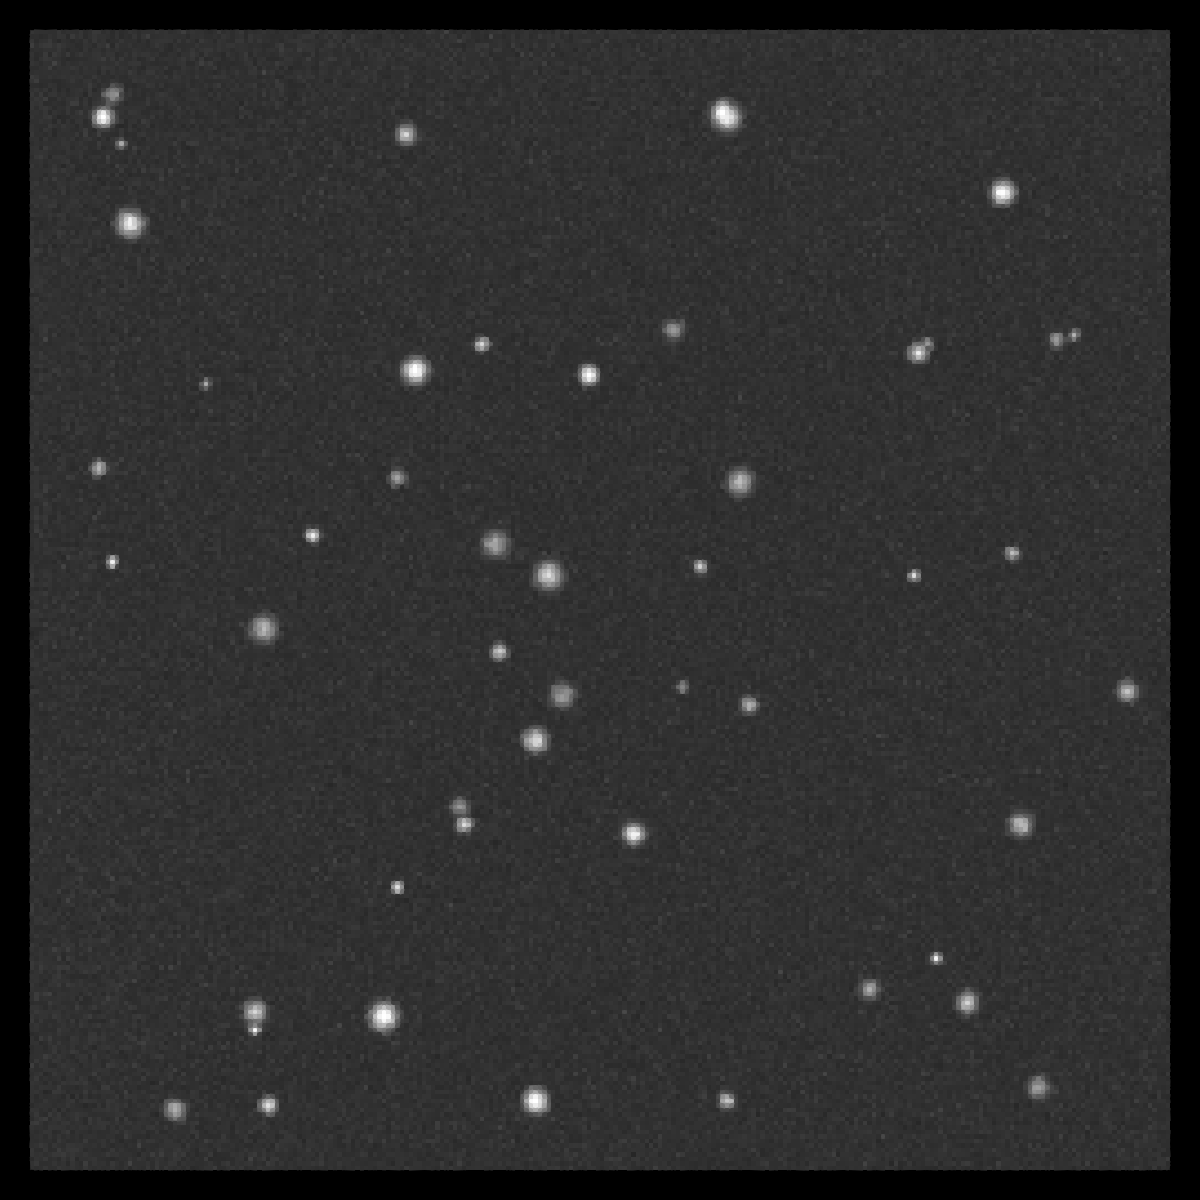

In [8]:
viewer.widget().children[1].snapshot()

### Initialize the Model

For 3D datasets, we need to use a pre-trained model that has been trained on 3D data, either `synth_3d` or `smfish_3d`. In this example, we will use the `smfish_3d` model.

In [9]:
model = Spotiflow.from_pretrained("smfish_3d")

INFO:spotiflow.model.spotiflow:Loading pretrained model: smfish_3d


### Run Spotiflow

In this example we are using a single-channel z-stack, so we can use the `predict()` method from the initialized model. we also do not need to transpose the image since it is already in the required `(Z, Y, X)` format.

In [10]:
points, details = model.predict(image_3d)

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.4], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (256, 256, 256)
INFO:spotiflow.model.spotiflow:Predicting with (2, 1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 256, 256, 1)
INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


Predicting tiles:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 50 spots


### Display and Save the Results

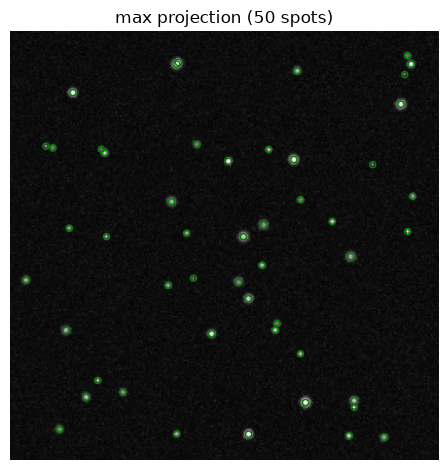

In [14]:
plot_points_by_channel(image_3d, points, colors=["green"], is_3d=True)

In [ ]:
save_points_as_csv(points, ".path/to/your/folder/points_3d.csv")

In [16]:
ndv.imshow(
    details.heatmap,
    default_lut={"cmap": "hot"},
    scales={0: 0.3, 1: 0.1, 2: 0.1},
    visible_axes=(0, 1, 2)  # to show the 3d volume
)

RFBOutputContext()

<IPython.core.display.Javascript object>

In [17]:
viewer = ndv.imshow(
    details.heatmap,
    default_lut={"cmap": "hot"},
    scales={0: 0.3, 1: 0.1, 2: 0.1},
    visible_axes=(0, 1, 2)  # to show the 3d volume
)

RFBOutputContext()

<IPython.core.display.Javascript object>


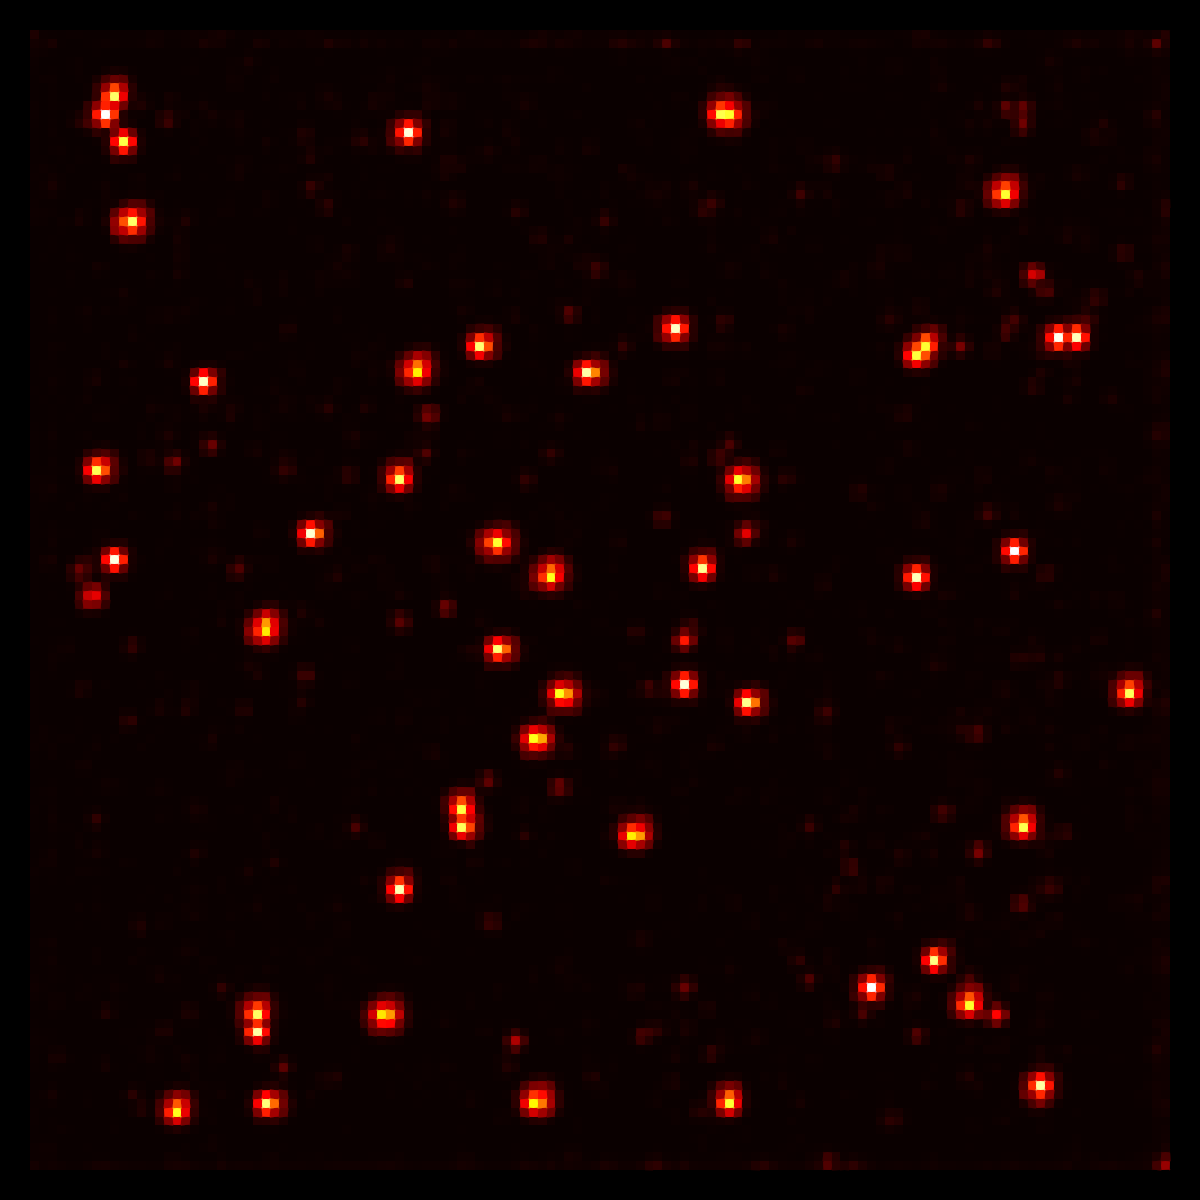

In [18]:
viewer.widget().children[1].snapshot()